# Conformal Prediction for Directed Graph Link Prediction on OGB Citation2

This notebook applies **split conformal prediction** to the **ogbl-citation2** dataset from the Open Graph Benchmark.

## Dataset: ogbl-citation2
- **Nodes**: 2,927,963 (academic papers)
- **Edges**: 30,561,187 (directed citations)
- **Task**: Predict missing citations between papers

## Key Methodology
1. **Directed SVD embeddings**: Separate source and target embeddings
2. **Mondrian conformal prediction**: Label-conditional coverage guarantees
3. **OGB-style edge splitting**: Message edges for representation, supervision edges for training

In [1]:
pip install ogb scikit-network

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.8/78.8 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 59.9 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score
from sknetwork.embedding import SVD
import torch

# OGB for loading the dataset (non-PyG version)
from ogb.linkproppred import LinkPropPredDataset

RNG_SEED = 42
print("Imports ready.")

Imports ready.


## 1. Mathematical Foundations

### 1.1 Directed Graph Representation

A directed graph $G = (V, E)$ consists of:
- Vertices $V = \{v_1, v_2, \ldots, v_n\}$
- Directed edges $E \subseteq V \times V$, where $(u, v) \in E$ represents $u \to v$

The adjacency matrix $A \in \{0,1\}^{n \times n}$:
$$A_{ij} = \begin{cases} 1 & \text{if } (v_i \to v_j) \in E \\ 0 & \text{otherwise} \end{cases}$$

### 1.2 Mondrian Conformal Quantiles

For each class $y \in \{0, 1\}$:
$$k_y = \lceil (n_y + 1)(1 - \alpha) \rceil$$
$$q_y = s^{(y)}_{(k_y)}$$

**Probability thresholds**:
$$t_{\text{upper}} = 1 - q_1, \quad t_{\text{lower}} = q_0$$

This ensures marginal coverage: $\mathbb{P}(Y \in C(X)) \geq 1 - \alpha$

In [3]:
# =============================================================================
# Helper Functions
# =============================================================================

def conformal_quantile(scores, alpha):
    """Mondrian conformal quantile."""
    n = len(scores)
    k = int(np.ceil((n + 1) * (1 - alpha)))
    return np.inf if k > n else np.sort(scores)[k - 1]

def get_node_features(adj, n_components=32):
    """Extract node features via SVD for directed graphs using sknetwork."""
    out_deg = np.array(adj.sum(axis=1)).flatten()
    in_deg = np.array(adj.sum(axis=0)).flatten()
    
    print(f"Computing SVD with {n_components} components using sknetwork...")
    svd = SVD(n_components=n_components)
    svd.fit(adj)
    src_emb = svd.embedding_      # Left embedding (source nodes)
    tgt_emb = svd.embedding_col_  # Right embedding (target nodes)
    
    return out_deg, in_deg, src_emb, tgt_emb

def compute_pair_features(pairs, out_deg, in_deg, src_emb, tgt_emb):
    """Compute directed edge features."""
    u, v = pairs[:, 0], pairs[:, 1]

    vec_u_src, vec_v_tgt = src_emb[u], tgt_emb[v]
    norm_u = np.linalg.norm(vec_u_src, axis=1)
    norm_v = np.linalg.norm(vec_v_tgt, axis=1)
    norm_u[norm_u == 0], norm_v[norm_v == 0] = 1e-9, 1e-9
    sim_fwd = np.sum(vec_u_src * vec_v_tgt, axis=1) / (norm_u * norm_v)

    vec_v_src, vec_u_tgt = src_emb[v], tgt_emb[u]
    norm_v2 = np.linalg.norm(vec_v_src, axis=1)
    norm_u2 = np.linalg.norm(vec_u_tgt, axis=1)
    norm_v2[norm_v2 == 0], norm_u2[norm_u2 == 0] = 1e-9, 1e-9
    sim_rev = np.sum(vec_v_src * vec_u_tgt, axis=1) / (norm_v2 * norm_u2)

    return np.column_stack([out_deg[u], in_deg[v], in_deg[u], out_deg[v], sim_fwd, sim_rev])

def set_metrics(y_true, sets):
    """Compute CP metrics: coverage, avg_set_size, retention, decided_acc."""
    y_true = np.asarray(y_true)
    sizes = np.array([len(s) for s in sets])
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    avg_set_size = np.mean(sizes)
    retention = np.mean(sizes == 1)

    decided_idx = np.where(sizes == 1)[0]
    if len(decided_idx) > 0:
        y_dec = y_true[decided_idx]
        pred_dec = np.array([next(iter(sets[i])) for i in decided_idx])
        acc_dec = np.mean(pred_dec == y_dec)
    else:
        acc_dec = np.nan

    return {
        "coverage": coverage,
        "avg_set_size": avg_set_size,
        "retention": retention,
        "decided_acc": acc_dec,
    }

def risk_coverage_curve(y_true, p):
    """Compute risk-coverage curve for selective prediction."""
    y_true = np.asarray(y_true)
    conf = np.abs(p - 0.5)
    order = np.argsort(-conf)
    correct = ((p >= 0.5).astype(int) == y_true).astype(float)
    cum_correct = np.cumsum(correct[order])
    coverages = np.arange(1, len(y_true) + 1) / len(y_true)
    risks = 1 - cum_correct / np.arange(1, len(y_true) + 1)
    return coverages, risks

def aurc(coverages, risks):
    """Compute Area Under Risk-Coverage curve (lower is better)."""
    return float(np.trapz(risks, coverages))

def cp_sets_from_thresholds(p, t_lower, t_upper):
    """Generate CP prediction sets from probability thresholds."""
    sets = []
    for pi in p:
        s = set()
        if pi <= t_lower:
            s.add(0)
        if pi >= t_upper:
            s.add(1)
        if len(s) == 0:
            s = {0, 1}  # abstain on empty
        sets.append(s)
    return sets

print("Helper functions ready.")

Helper functions ready.


## 2. Load OGB Citation2 Dataset

In [4]:
import os
import torch

from ogb.linkproppred import LinkPropPredDataset
import ogb.utils.url as ogb_url
import ogb.linkproppred.dataset as ogb_lp_dataset

def _always_yes(_):
    return True

# Patch both places:
ogb_url.decide_download = _always_yes
ogb_lp_dataset.decide_download = _always_yes

print("Loading ogbl-citation2 dataset...")
dataset = LinkPropPredDataset(name="ogbl-citation2")

# Get the graph
graph = dataset[0]

split_path = os.path.join(dataset.root, "split", "time")
split_edge = {
    "train": torch.load(os.path.join(split_path, "train.pt"), weights_only=False),
    "valid": torch.load(os.path.join(split_path, "valid.pt"), weights_only=False),
    "test": torch.load(os.path.join(split_path, "test.pt"), weights_only=False),
}

print(f"\nDataset loaded:")
print(f"  Nodes: {graph['num_nodes']:,}")
print(f"  Edges: {graph['edge_index'].shape[1]:,}")
print(f"\nEdge split sizes:")
print(f"  Train: {split_edge['train']['source_node'].shape[0]:,}")
print(f"  Valid: {split_edge['valid']['source_node'].shape[0]:,}")
print(f"  Test: {split_edge['test']['source_node'].shape[0]:,}")


Loading ogbl-citation2 dataset...


Downloaded 2.14 GB: 100%|██████████| 2189/2189 [01:57<00:00, 18.66it/s]


Extracting dataset/citation-v2.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 6898.53it/s]

Saving...



Dataset loaded:
  Nodes: 2,927,963
  Edges: 30,387,995

Edge split sizes:
  Train: 30,387,995
  Valid: 86,596
  Test: 86,596


In [5]:
# Build adjacency matrix from training edges
n_nodes = graph['num_nodes']

# Get training edges (already numpy arrays in non-PyG version)
train_source = split_edge['train']['source_node']
train_target = split_edge['train']['target_node']

print(f"Building adjacency matrix from {len(train_source):,} training edges...")

adj = sp.csr_matrix(
    (np.ones(len(train_source)), (train_source, train_target)),
    shape=(n_nodes, n_nodes)
)
adj.setdiag(0)
adj.eliminate_zeros()

print(f"Adjacency matrix: {adj.shape[0]:,} x {adj.shape[1]:,}, {adj.nnz:,} edges")

Building adjacency matrix from 30,387,995 training edges...
Adjacency matrix: 2,927,963 x 2,927,963, 30,387,995 edges


## 3. Run Conformal Prediction Pipeline

Due to the large size of the dataset, we'll use a subsample for efficient experimentation.

### Methodology
1. Use OGB's temporal edge split (train/valid/test)
2. Compute SVD embeddings on training graph
3. Train classifier on supervision edges
4. Calibrate CP thresholds on validation set
5. Evaluate on test set

In [6]:
FEATURE_NAMES = ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']

def run_pipeline_ogb(adj, split_edge, name, alpha=0.10, n_runs=5, n_components=32, 
                     msg_ratio=0.7, sample_size=100000):
    """
    Run directed graph link prediction with conformal prediction on OGB dataset.
    
    Parameters:
    -----------
    adj : sparse matrix
        Adjacency matrix built from training edges
    split_edge : dict
        OGB edge split containing train/valid/test edges
    sample_size : int
        Number of edges to sample for calibration/test (for efficiency)
    """
    print(f"\n{'='*70}")
    print(f"Pipeline: {name.upper()} | {n_runs} runs")
    print(f"{'='*70}")

    n_nodes = adj.shape[0]
    print(f"Graph: {n_nodes:,} nodes, {adj.nnz:,} edges")
    
    # Get all positive edges for negative sampling exclusion (already numpy arrays)
    train_edges = np.column_stack([split_edge['train']['source_node'], 
                                   split_edge['train']['target_node']])
    valid_edges = np.column_stack([split_edge['valid']['source_node'], 
                                   split_edge['valid']['target_node']])
    test_edges = np.column_stack([split_edge['test']['source_node'], 
                                  split_edge['test']['target_node']])
    
    all_pos_set = set(map(tuple, np.vstack([train_edges, valid_edges, test_edges])))
    print(f"Total positive edges for exclusion: {len(all_pos_set):,}")

    run_results = []
    last_run_data = {}
    all_feature_importances = []

    for seed in range(n_runs):
        rng = np.random.default_rng(seed)
        print(f"\nRun {seed+1}/{n_runs}...")

        # OGB-style split: message (SVD) + supervision (classifier)
        n_train = len(train_edges)
        n_msg = int(n_train * msg_ratio)

        train_idx = rng.permutation(n_train)
        E_msg = train_edges[train_idx[:n_msg]]
        E_sup = train_edges[train_idx[n_msg:]]
        
        # Sample calibration and test edges for efficiency
        if sample_size is None:
            E_cal = valid_edges
            E_test = test_edges
        else:
            n_cal_sample = min(sample_size, len(valid_edges))
            n_test_sample = min(sample_size, len(test_edges))
        
            cal_idx = rng.choice(len(valid_edges), n_cal_sample, replace=False)
            test_idx = rng.choice(len(test_edges), n_test_sample, replace=False)
        
            E_cal = valid_edges[cal_idx]
            E_test = test_edges[test_idx]
        
        # Also sample supervision edges only if sample_size is set
        if sample_size is not None:
            sup_sample_size = min(sample_size * 2, len(E_sup))
            if len(E_sup) > sup_sample_size:
                sup_idx = rng.choice(len(E_sup), sup_sample_size, replace=False)
                E_sup = E_sup[sup_idx]
        # Build representation graph from MESSAGE edges only
        adj_msg = sp.csr_matrix(
            (np.ones(len(E_msg)), (E_msg[:, 0], E_msg[:, 1])), 
            shape=(n_nodes, n_nodes)
        )
        adj_msg.setdiag(0)
        adj_msg.eliminate_zeros()

        out_deg, in_deg, src_emb, tgt_emb = get_node_features(adj_msg, n_components)
        known_edges_set = set(map(tuple, np.vstack([E_msg, E_sup])))

        def make_dataset(pos_edges, exclude_set, all_pos_set):
            neg_edges = set()
            attempts = 0
            max_attempts = len(pos_edges) * 10
            
            while len(neg_edges) < len(pos_edges) and attempts < max_attempts:
                u, v = rng.integers(0, n_nodes, 2)
                if u != v and (u, v) not in exclude_set and (u, v) not in all_pos_set:
                    neg_edges.add((u, v))
                attempts += 1
            
            neg_edges = np.array(list(neg_edges))
            if len(neg_edges) < len(pos_edges):
                pos_edges = pos_edges[:len(neg_edges)]

            X_pos = compute_pair_features(pos_edges, out_deg, in_deg, src_emb, tgt_emb)
            X_neg = compute_pair_features(neg_edges, out_deg, in_deg, src_emb, tgt_emb)
            X = np.vstack([X_pos, X_neg])
            y = np.hstack([np.ones(len(pos_edges)), np.zeros(len(neg_edges))])
            pairs = np.vstack([pos_edges, neg_edges])
            return X, y, pairs

        print("  Creating datasets...")
        X_train, y_train, _ = make_dataset(E_sup, known_edges_set, all_pos_set)
        cal_exclude = known_edges_set | set(map(tuple, E_cal))
        X_cal, y_cal, _ = make_dataset(E_cal, cal_exclude, all_pos_set)
        X_test, y_test, test_pairs = make_dataset(E_test, known_edges_set, all_pos_set)

        print(f"  Train: {len(y_train):,}, Cal: {len(y_cal):,}, Test: {len(y_test):,}")
        
        print("  Training classifier...")
        clf = GradientBoostingClassifier(random_state=seed, n_estimators=100)
        clf.fit(X_train, y_train)

        p_cal = clf.predict_proba(X_cal)[:, 1]
        p_test = clf.predict_proba(X_test)[:, 1]

        # Store feature importances
        all_feature_importances.append(clf.feature_importances_)

        # CP thresholds on full calibration set
        scores_pos = 1 - p_cal[y_cal == 1]
        scores_neg = p_cal[y_cal == 0]
        q1 = conformal_quantile(scores_pos, alpha)
        q0 = conformal_quantile(scores_neg, alpha)
        t_lower, t_upper = q0, 1 - q1

        # Evaluate on TEST
        cp_sets_test = cp_sets_from_thresholds(p_test, t_lower, t_upper)
        cp_m = set_metrics(y_test, cp_sets_test)

        # AUC and AURC
        auc = roc_auc_score(y_test, p_test)
        rc_cov, rc_risk = risk_coverage_curve(y_test, p_test)
        aurc_val = aurc(rc_cov, rc_risk)

        run_results.append({
            "AUC": auc,
            "AURC": aurc_val,
            "CP Coverage": cp_m['coverage'],
            "CP Avg Set Size": cp_m['avg_set_size'],
            "CP Retention": cp_m['retention'],
            "CP Decided Acc": cp_m['decided_acc'],
        })

        last_run_data = {
            'y_test': y_test, 'p_test': p_test, 'cp_sets_test': cp_sets_test,
            't_lower': t_lower, 't_upper': t_upper,
            'auc': auc, 'aurc': aurc_val, 'rc_cov': rc_cov, 'rc_risk': rc_risk,
            'feature_importances': clf.feature_importances_,
        }

        print(f"  AUC={auc:.4f} | AURC={aurc_val:.4f} | "
              f"CP[Cov={cp_m['coverage']:.3f}, Ret={cp_m['retention']:.3f}, Acc={cp_m['decided_acc']:.3f}]")

    # Aggregate results
    df = pd.DataFrame(run_results)
    means = df.mean()
    stds = df.std()

    # Compute mean and std of feature importances across runs
    feature_importances_mean = np.mean(all_feature_importances, axis=0)
    feature_importances_std = np.std(all_feature_importances, axis=0)

    print(f"\n{'='*60}")
    print(f"RESULTS ({name.upper()})")
    print(f"{'='*60}")
    print(f"  AUC             : {means['AUC']:.4f} +/- {stds['AUC']:.4f}")
    print(f"  AURC            : {means['AURC']:.4f} +/- {stds['AURC']:.4f}")
    print(f"\n--- CP (alpha={alpha}) ---")
    print(f"  Coverage        : {means['CP Coverage']:.4f} +/- {stds['CP Coverage']:.4f}  (target: {1-alpha:.2f})")
    print(f"  Avg Set Size    : {means['CP Avg Set Size']:.4f} +/- {stds['CP Avg Set Size']:.4f}")
    print(f"  Retention       : {means['CP Retention']:.4f} +/- {stds['CP Retention']:.4f}")
    print(f"  Decided Acc     : {means['CP Decided Acc']:.4f} +/- {stds['CP Decided Acc']:.4f}")

    # Visualization (3 plots)
    y_test, p_test = last_run_data['y_test'], last_run_data['p_test']
    t_lower, t_upper = last_run_data['t_lower'], last_run_data['t_upper']
    cp_sets = last_run_data['cp_sets_test']
    rc_cov, rc_risk = last_run_data['rc_cov'], last_run_data['rc_risk']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'{name.upper()} Results', fontsize=14, fontweight='bold')

    # Plot 1: Risk-Coverage curve
    ax = axes[0]
    ax.plot(rc_cov, rc_risk, color='purple', linewidth=2, label=f'AURC={last_run_data["aurc"]:.4f}')
    ax.fill_between(rc_cov, rc_risk, alpha=0.3, color='purple')
    ax.set_xlabel('Coverage'); ax.set_ylabel('Risk (1 - Accuracy)')
    ax.set_title('Risk-Coverage Curve'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 2: Probability distributions
    ax = axes[1]
    ax.hist(p_test[y_test == 0], bins=30, alpha=0.5, color='red', label='No Edge', density=True)
    ax.hist(p_test[y_test == 1], bins=30, alpha=0.5, color='blue', label='Edge', density=True)
    ax.axvline(t_lower, color='red', linestyle='--', linewidth=2, label=f't_lower={t_lower:.3f}')
    ax.axvline(t_upper, color='blue', linestyle='--', linewidth=2, label=f't_upper={t_upper:.3f}')
    ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Density')
    ax.set_title('CP Thresholds'); ax.legend(); ax.grid(alpha=0.3)

    # Plot 3: Set sizes
    ax = axes[2]
    sizes = [len(s) for s in cp_sets]
    unique, counts = np.unique(sizes, return_counts=True)
    colors_bar = ['green' if u == 1 else 'orange' for u in unique]
    ax.bar(unique, counts, color=colors_bar, alpha=0.7)
    ax.set_xlabel('Set Size'); ax.set_ylabel('Count')
    ax.set_title(f'Set Size Distribution (Ret={means["CP Retention"]:.1%})')
    ax.set_xticks(unique); ax.set_xticklabels(['Decided' if u == 1 else 'Abstain' for u in unique])
    ax.grid(alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()

    return {
        'name': name, 
        'df': df, 
        'means': df.mean().to_dict(), 
        'last_run': last_run_data,
        'feature_importances_mean': feature_importances_mean,
        'feature_importances_std': feature_importances_std,
    }

print("Pipeline ready.")

Pipeline ready.



Pipeline: OGBL-CITATION2 | 10 runs
Graph: 2,927,963 nodes, 30,387,995 edges
Total positive edges for exclusion: 30,561,187

Run 1/10...
Computing SVD with 32 components using sknetwork...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3592304167.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9429 | AURC=0.0378 | CP[Cov=0.899, Ret=0.915, Acc=0.890]

Run 2/10...
Computing SVD with 32 components using sknetwork...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3592304167.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9431 | AURC=0.0373 | CP[Cov=0.901, Ret=0.913, Acc=0.892]

Run 3/10...
Computing SVD with 32 components using sknetwork...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


...

  AUC=0.9430 | AURC=0.0375 | CP[Cov=0.900, Ret=0.912, Acc=0.891]

Run 9/10...
Computing SVD with 32 components using sknetwork...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3592304167.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9443 | AURC=0.0370 | CP[Cov=0.902, Ret=0.916, Acc=0.893]

Run 10/10...
Computing SVD with 32 components using sknetwork...
  Creating datasets...
  Train: 2,000,000, Cal: 173,192, Test: 173,192
  Training classifier...


/tmp/ipykernel_17/3592304167.py:78: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return float(np.trapz(risks, coverages))


  AUC=0.9440 | AURC=0.0369 | CP[Cov=0.900, Ret=0.918, Acc=0.891]

RESULTS (OGBL-CITATION2)
  AUC             : 0.9434 +/- 0.0005
  AURC            : 0.0374 +/- 0.0003

--- CP (alpha=0.1) ---
  Coverage        : 0.9007 +/- 0.0008  (target: 0.90)
  Avg Set Size    : 1.0857 +/- 0.0021
  Retention       : 0.9143 +/- 0.0021
  Decided Acc     : 0.8914 +/- 0.0009


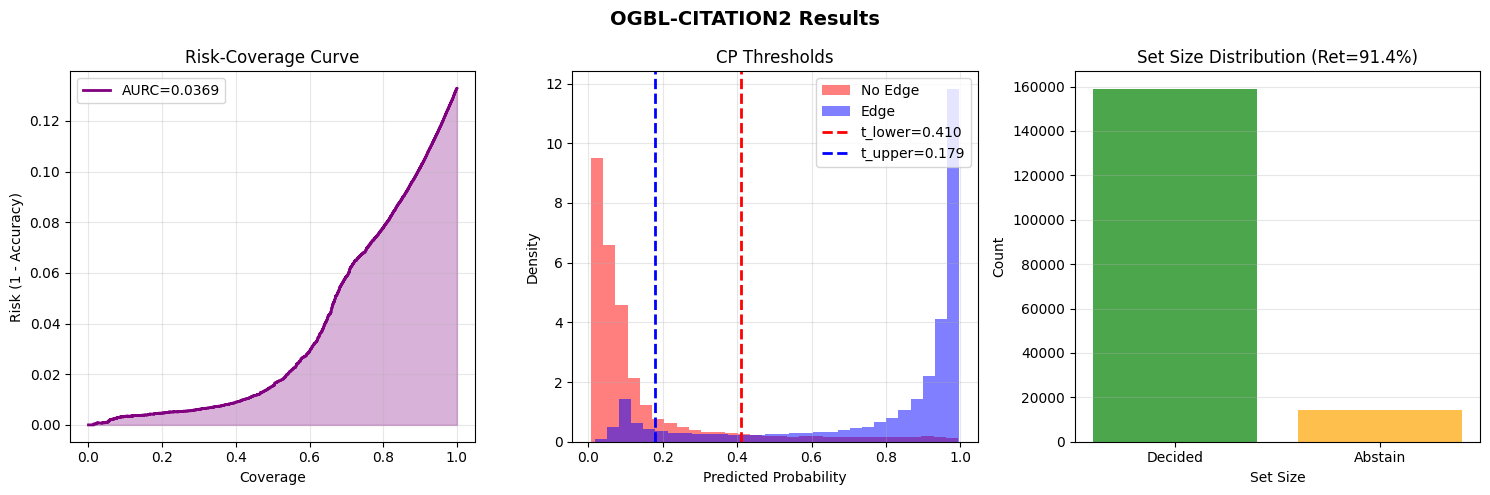

In [7]:
# Run the pipeline on ogbl-citation2
# Using sample_size=50000 for efficiency (the full dataset has millions of edges)
result = run_pipeline_ogb(
    adj=adj,
    split_edge=split_edge,
    name='ogbl-citation2',
    alpha=0.10,
    n_runs=10,
    n_components=32,
    sample_size=500000
)


FEATURE IMPORTANCE ANALYSIS - OGB Citation2
Features: ['out_deg_u', 'in_deg_v', 'in_deg_u', 'out_deg_v', 'sim_forward', 'sim_reverse']


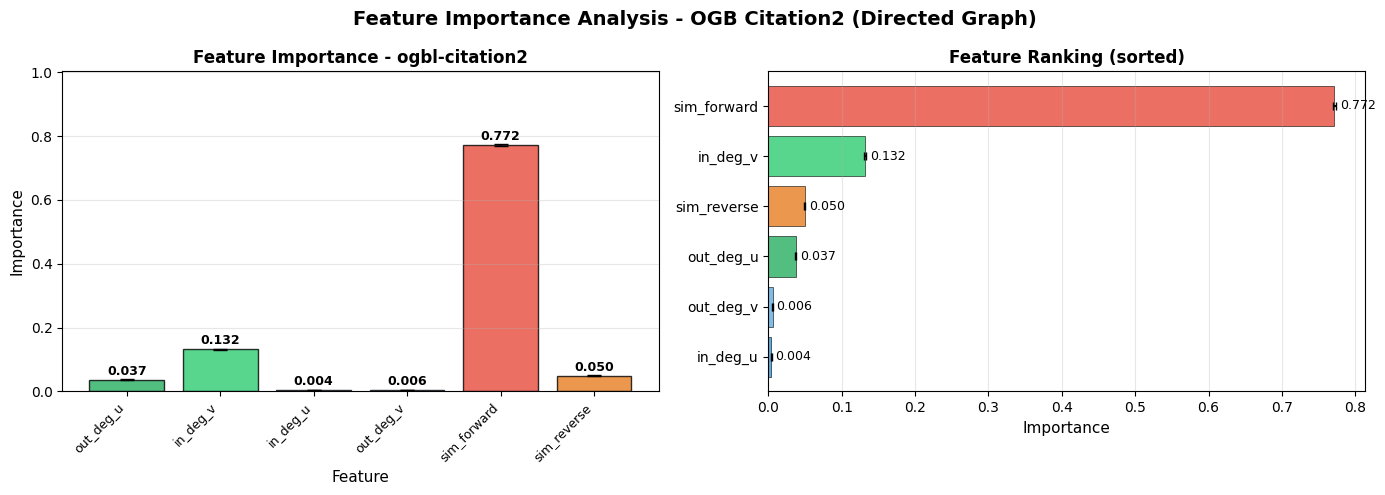


--- Feature Importance Summary ---
Feature         |   Importance |        Std
---------------------------------------------
out_deg_u       |       0.0371 |     0.0011
in_deg_v        |       0.1319 |     0.0016
in_deg_u        |       0.0042 |     0.0003
out_deg_v       |       0.0057 |     0.0004
sim_forward     |       0.7715 |     0.0025
sim_reverse     |       0.0495 |     0.0007

--- Feature Groups Analysis ---
Degree features: out_deg_u, in_deg_v, in_deg_u, out_deg_v
Similarity features: sim_forward, sim_reverse

Degree features total:     0.1789 (17.9%)
Similarity features total: 0.8211 (82.1%)

--- Feature Ranking (by importance) ---
  1. sim_forward    : 0.7715 +/- 0.0025
  2. in_deg_v       : 0.1319 +/- 0.0016
  3. sim_reverse    : 0.0495 +/- 0.0007
  4. out_deg_u      : 0.0371 +/- 0.0011
  5. out_deg_v      : 0.0057 +/- 0.0004
  6. in_deg_u       : 0.0042 +/- 0.0003


In [8]:
# =============================================================================
# Feature Importance Analysis (6 Directed Features)
# =============================================================================
print("\n" + "="*80)
print("FEATURE IMPORTANCE ANALYSIS - OGB Citation2")
print("="*80)
print(f"Features: {FEATURE_NAMES}")

# Get feature importances from result
feature_importances_mean = result['feature_importances_mean']
feature_importances_std = result['feature_importances_std']

# Create figure with 2 subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Colors for 6 features: degree features (greens/blues) and similarity features (reds/oranges)
colors = ['#27ae60', '#2ecc71', '#3498db', '#5dade2', '#e74c3c', '#e67e22']
# out_deg_u, in_deg_v, in_deg_u, out_deg_v, sim_forward, sim_reverse

# Plot 1: Bar chart with error bars
ax = axes[0]
x = np.arange(len(FEATURE_NAMES))
bars = ax.bar(x, feature_importances_mean, yerr=feature_importances_std, 
              color=colors, alpha=0.8, capsize=5, edgecolor='black', linewidth=1)

ax.set_xlabel('Feature', fontsize=11)
ax.set_ylabel('Importance', fontsize=11)
ax.set_title(f'Feature Importance - {result["name"]}', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(FEATURE_NAMES, fontsize=9, rotation=45, ha='right')
ax.set_ylim(0, max(feature_importances_mean) * 1.3)
ax.grid(alpha=0.3, axis='y')

# Add value labels on bars
for bar, val, std in zip(bars, feature_importances_mean, feature_importances_std):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + std + 0.005, 
            f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Horizontal bar chart (sorted by importance)
ax = axes[1]
sorted_idx = np.argsort(feature_importances_mean)
sorted_names = [FEATURE_NAMES[i] for i in sorted_idx]
sorted_values = feature_importances_mean[sorted_idx]
sorted_stds = feature_importances_std[sorted_idx]
sorted_colors = [colors[i] for i in sorted_idx]

y_pos = np.arange(len(FEATURE_NAMES))
bars = ax.barh(y_pos, sorted_values, xerr=sorted_stds, color=sorted_colors, 
               alpha=0.8, capsize=3, edgecolor='black', linewidth=0.5)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_names, fontsize=10)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Feature Ranking (sorted)', fontsize=12, fontweight='bold')
ax.grid(alpha=0.3, axis='x')

# Add value labels
for i, (val, std) in enumerate(zip(sorted_values, sorted_stds)):
    ax.text(val + std + 0.005, i, f'{val:.3f}', va='center', fontsize=9)

plt.suptitle('Feature Importance Analysis - OGB Citation2 (Directed Graph)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Print feature importance summary
print("\n--- Feature Importance Summary ---")
print(f"{'Feature':<15} | {'Importance':>12} | {'Std':>10}")
print("-" * 45)
for i, feat in enumerate(FEATURE_NAMES):
    print(f"{feat:<15} | {feature_importances_mean[i]:>12.4f} | {feature_importances_std[i]:>10.4f}")

# Feature groups analysis
print("\n--- Feature Groups Analysis ---")
print("Degree features: out_deg_u, in_deg_v, in_deg_u, out_deg_v")
print("Similarity features: sim_forward, sim_reverse")
deg_importance = sum(feature_importances_mean[:4])
sim_importance = sum(feature_importances_mean[4:])
print(f"\nDegree features total:     {deg_importance:.4f} ({deg_importance*100:.1f}%)")
print(f"Similarity features total: {sim_importance:.4f} ({sim_importance*100:.1f}%)")

# Feature ranking
print("\n--- Feature Ranking (by importance) ---")
ranked_indices = np.argsort(feature_importances_mean)[::-1]
for rank, idx in enumerate(ranked_indices, 1):
    print(f"  {rank}. {FEATURE_NAMES[idx]:<15}: {feature_importances_mean[idx]:.4f} +/- {feature_importances_std[idx]:.4f}")


NAIVE BASELINE vs CONFORMAL PREDICTION

Naive Baseline: Predict {1} if p > 0.5, else {0}
This uses a fixed threshold without any calibration.

Coverage Comparison for OGB Citation2:
------------------------------------------------------------
Method                         |   Coverage |   Hits 90%
------------------------------------------------------------
Naive Baseline (p > 0.5)       |     0.8671 |          ✓
Conformal Prediction (α=0.10)  |     0.9007 |          ✓
------------------------------------------------------------


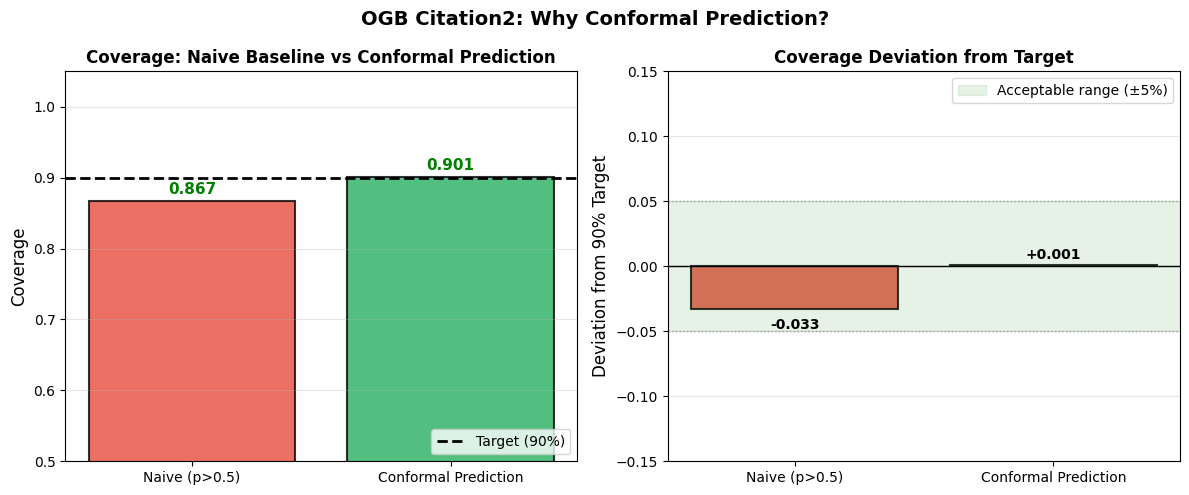

In [9]:
# =============================================================================
# NAIVE BASELINE vs CONFORMAL PREDICTION COMPARISON
# =============================================================================
# Demonstrate that a naive fixed-threshold baseline (predict {1} if p > 0.5)
# has unpredictable coverage, while CP consistently hits 90%.

print("\n" + "="*80)
print("NAIVE BASELINE vs CONFORMAL PREDICTION")
print("="*80)
print("\nNaive Baseline: Predict {1} if p > 0.5, else {0}")
print("This uses a fixed threshold without any calibration.\n")

def naive_baseline_sets(p, threshold=0.5):
    """Generate naive prediction sets using a fixed threshold."""
    sets = []
    for pi in p:
        if pi > threshold:
            sets.append({1})
        else:
            sets.append({0})
    return sets

def naive_baseline_metrics(y_true, p, threshold=0.5):
    """Compute metrics for naive baseline."""
    sets = naive_baseline_sets(p, threshold)
    y_true = np.asarray(y_true)
    
    # Coverage: fraction where true label is in prediction set
    coverage = np.mean([y in s for y, s in zip(y_true, sets)])
    
    # Accuracy (same as coverage for singleton sets)
    preds = (p > threshold).astype(int)
    accuracy = np.mean(preds == y_true)
    
    return {
        "coverage": coverage,
        "accuracy": accuracy,
    }

# Compute naive baseline using last run data
y_test = result['last_run']['y_test']
p_test = result['last_run']['p_test']

naive_m = naive_baseline_metrics(y_test, p_test, threshold=0.5)
cp_coverage = result['means']['CP Coverage']

print("Coverage Comparison for OGB Citation2:")
print("-" * 60)
print(f"{'Method':<30} | {'Coverage':>10} | {'Hits 90%':>10}")
print("-" * 60)
print(f"{'Naive Baseline (p > 0.5)':<30} | {naive_m['coverage']:>10.4f} | {'✓' if abs(naive_m['coverage'] - 0.9) < 0.05 else '✗':>10}")
print(f"{'Conformal Prediction (α=0.10)':<30} | {cp_coverage:>10.4f} | {'✓' if abs(cp_coverage - 0.9) < 0.05 else '✗':>10}")
print("-" * 60)

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Coverage comparison bar chart
ax = axes[0]
methods = ['Naive (p>0.5)', 'Conformal Prediction']
coverages = [naive_m['coverage'], cp_coverage]
colors = ['#e74c3c', '#27ae60']

bars = ax.bar(methods, coverages, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axhline(0.9, color='black', linestyle='--', linewidth=2, label='Target (90%)')
ax.set_ylabel('Coverage', fontsize=12)
ax.set_title('Coverage: Naive Baseline vs Conformal Prediction', fontsize=12, fontweight='bold')
ax.set_ylim(0.5, 1.05)
ax.legend(loc='lower right')
ax.grid(alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, coverages):
    color = 'green' if abs(val - 0.9) < 0.05 else 'red'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f'{val:.3f}', 
            ha='center', fontsize=11, color=color, fontweight='bold')

# Plot 2: Coverage deviation from target
ax = axes[1]
deviations = [cov - 0.9 for cov in coverages]

bars = ax.bar(methods, deviations, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
ax.axhline(0, color='black', linestyle='-', linewidth=1)
ax.axhline(0.05, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.axhline(-0.05, color='gray', linestyle=':', linewidth=1, alpha=0.7)
ax.axhspan(-0.05, 0.05, alpha=0.1, color='green', label='Acceptable range (±5%)')

ax.set_ylabel('Deviation from 90% Target', fontsize=12)
ax.set_title('Coverage Deviation from Target', fontsize=12, fontweight='bold')
ax.set_ylim(-0.15, 0.15)
ax.legend(loc='upper right')
ax.grid(alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, deviations):
    offset = 0.005 if val >= 0 else -0.015
    ax.text(bar.get_x() + bar.get_width()/2, val + offset, f'{val:+.3f}', 
            ha='center', fontsize=10, fontweight='bold')

plt.suptitle('OGB Citation2: Why Conformal Prediction?', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

